In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv('train.csv')
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
test = pd.read_csv('test.csv')
test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


In [ ]:
train.shape

(7352, 563)

In [ ]:
cols_subset = [
    'tBodyAccMag-mean()',  # усредненная величина ускорения тела
    'tBodyGyroJerk-mad()-X',  # медианная величина рывка тела по оси Х
    'tGravityAcc-min()-X',  # минимум гравитационной составляющей ускорения по оси Х
    'tBodyAcc-max()-X',  # максимальная величина ускорения тела по оси Х
    'fBodyAcc-bandsEnergy()-1,8.2',  # энергия ускорения тела в интервале частоты
    'angle(X,gravityMean)',  # угол между осью Х и усредненной гравитационной составляющей ускорения
    'angle(Y,gravityMean)',  # угол между осью Y и усредненной гравитационной составляющей ускорения
    'angle(Z,gravityMean)',  # угол между осью Z и усредненной гравитационной составляющей ускорения,
    'fBodyAcc-skewness()-X',  # асимметричность частоты ускорения тела по оси Х
    'subject',  # номер испытуемого
    'Activity',  # название вида деятельности (целевая переменная)
]

In [ ]:
train = train[cols_subset]
train.head()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
0,-0.959434,-0.992165,0.977436,-0.934724,-0.993592,-0.841247,0.179941,-0.058627,0.142051,1,STANDING
1,-0.979289,-0.989876,0.984520,-0.943068,-0.998235,-0.844788,0.180289,-0.054317,-0.692541,1,STANDING
2,-0.983703,-0.987868,0.986770,-0.938692,-0.999388,-0.848933,0.180637,-0.049118,-0.727227,1,STANDING
3,-0.986542,-0.991241,0.986821,-0.938692,-0.999807,-0.848649,0.181935,-0.047663,-0.599118,1,STANDING
4,-0.992827,-0.992882,0.987434,-0.942469,-0.999806,-0.847865,0.185151,-0.043892,-0.676997,1,STANDING


In [ ]:
test = test[cols_subset]
test.head()

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
0,-0.866929,-0.910363,0.944461,-0.894088,-0.924705,-0.720009,0.276801,-0.057978,-0.571999,2,STANDING
1,-0.968961,-0.968614,0.944461,-0.894088,-0.997186,-0.698091,0.281343,-0.083898,-0.918176,2,STANDING
2,-0.976228,-0.983723,0.948704,-0.939260,-0.999083,-0.702771,0.280083,-0.079346,-0.384114,2,STANDING
3,-0.974325,-0.983995,0.947309,-0.938610,-0.999171,-0.698954,0.284114,-0.077108,-0.635581,2,STANDING
4,-0.975836,-0.988244,0.946221,-0.938610,-0.999355,-0.692245,0.290722,-0.073857,-0.507391,2,STANDING


# **Задание 1 (0.5 балла)**
Посмотрите на пропуски и дубли в данных train и test. Есть ли они? Если есть, напишите, с чем это может быть связано? Если нет, то просто напишите, что пропусков и/или дублей нет.

In [ ]:
missing_count_train = train.isna().sum()
missing_count_train

,0
tBodyAccMag-mean(),0
tBodyGyroJerk-mad()-X,0
tGravityAcc-min()-X,0
tBodyAcc-max()-X,0
"fBodyAcc-bandsEnergy()-1,8.2",0
"angle(X,gravityMean)",0
"angle(Y,gravityMean)",0
"angle(Z,gravityMean)",0
fBodyAcc-skewness()-X,0
subject,0


In [ ]:
missing_count_test = test.isna().sum()
missing_count_test

,0
tBodyAccMag-mean(),0
tBodyGyroJerk-mad()-X,0
tGravityAcc-min()-X,0
tBodyAcc-max()-X,0
"fBodyAcc-bandsEnergy()-1,8.2",0
"angle(X,gravityMean)",0
"angle(Y,gravityMean)",0
"angle(Z,gravityMean)",0
fBodyAcc-skewness()-X,0
subject,0


Пропусков в train и test нет

In [ ]:
common_rows = pd.merge(train, test, how='inner')
len(common_rows)

0

Дублей в данных train и test нет

# **Задание 2 (0.5 балла)**
Выведите основные статистики данных: среднее, медиана, перцентили (0.25, 0.5, 0.75), минимум, максимум, стандартное отклонение. Посмотрите на таблицу и напишите, видите ли вы в ней что-нибудь интересное.

In [ ]:
train.describe(include = "all")

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LAYING
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1407
mean,-0.543884,-0.727735,0.678505,-0.468604,-0.847963,-0.489547,0.058593,-0.056515,-0.128562,17.413085,NaN
std,0.477653,0.315832,0.508656,0.544547,0.233633,0.511807,0.297480,0.279122,0.403686,8.975143,NaN
min,-1.000000,-0.999889,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.931208,1.000000,NaN
25%,-0.983282,-0.991595,0.804270,-0.936219,-0.999480,-0.812065,-0.017885,-0.143414,-0.486841,8.000000,NaN
50%,-0.883371,-0.950268,0.926693,-0.881637,-0.986582,-0.709417,0.182071,0.003181,-0.163271,19.000000,NaN
75%,-0.106892,-0.474625,0.965095,-0.017129,-0.764508,-0.509079,0.248353,0.107659,0.155112,26.000000,NaN


In [ ]:
test.describe(include = "all")

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
count,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947.000000,2947
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LAYING
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,537
mean,-0.559043,-0.735661,0.696878,-0.462063,-0.880361,-0.513923,0.074886,-0.048720,-0.154042,12.986427,NaN
std,0.439539,0.282074,0.502873,0.523916,0.160496,0.509205,0.324300,0.241467,0.392203,6.950984,NaN
min,-0.998936,-1.000000,-0.756774,-0.952357,-0.999989,-0.984195,-0.913704,-0.949228,-1.000000,2.000000,NaN
25%,-0.978433,-0.989078,0.836787,-0.934447,-0.999330,-0.829722,0.022140,-0.098485,-0.497070,9.000000,NaN
50%,-0.861830,-0.914698,0.934930,-0.852659,-0.979336,-0.729648,0.181563,-0.010671,-0.202050,12.000000,NaN
75%,-0.149596,-0.486423,0.970871,-0.009965,-0.799113,-0.545939,0.260252,0.092373,0.140254,18.000000,NaN


Различия между обучающей и тестовой выборками для subject: Среднее значение subject значительно отличается (17.41 против 12.99). Это указывает на то, что распределение субъектов в двух наборах данных отличается

Отрицательные средние значения для tBodyAccMag-mean() и tBodyAcc-max()-X. Это может указывать на смещение в измерениях ускорения

Признаки, связанные с углами (angle(X,gravityMean), angle(Y,gravityMean), angle(Z,gravityMean)): Средние значения для этих признаков имеют значительный разброс (стандартные отклонения около 0.28-0.51). Это ожидаемо, поскольку углы могут быть как положительными, так и отрицательными

Энергия в частотных диапазонах (fBodyAcc-bandsEnergy()-1,8.2): Этот признак имеет очень большое отрицательное среднее значение (-0.85 для train и -0.88 для test) и небольшое стандартное отклонение. Это говорит о том, что в большинстве случаев в этом частотном диапазоне ускорения тела мало энергии (но я не физик, я международник, я не уверена)

Асимметрия в fBodyAcc-skewness()-X: Среднее значение (-0.13 для train и -0.15 для test) и медиана этого признака немного отличаются, что указывает на небольшую асимметрию в распределении

Разброс в tGravityAcc-min()-X: Несмотря на то, что большинство значений tGravityAcc-min()-X находятся вблизи максимума (медиана около 0.93), минимальные значения доходят до -1.0.

# **Задание 3 (0.5 балла)**
Данные сбалансированы? У вас есть 6 категорий активности (целевая переменная). Если одна из категорий представлена большим количеством наблюдений, а остальные - нет, то это обстоятельство, о котором хотелось бы знать заранее. Гиперболизированный пример: представьте, что у вас 1000 наблюдений, разделенных на два класса, и только 5 принадлежат ко второму классу. Как учить модель на такой выборке? Есть сильное подозрение, что многие модели будут склонны вырождаться в константу. Отсюда и необходимость проверять баланс классов.

Выведите количество наблюдений для всех категорий активности в train и test. Посчитайте разницу в процентах между самой крупной категорией и самой маленькой (самая большая категория - это 100%). Если разница (округленная до ближайшего целого числа) не превышает 30%, то давайте для наших целей считать, что данные сбалансированы. Напишите, сбалансированы ли данные в train и test.

In [ ]:
train_activity_counts = train['Activity'].value_counts()
print("Распределение классов в train:\n", train_activity_counts)

test_activity_counts = test['Activity'].value_counts()
print("\nРаспределение классов в test:\n", test_activity_counts)

Распределение классов в train:
 Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Распределение классов в test:
 Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


In [ ]:
def calculate_class_balance(counts):
    max_count = counts.max()
    min_count = counts.min()
    percentage_difference = ((max_count - min_count) / max_count) * 100
    return round(percentage_difference)

In [ ]:
train_difference = calculate_class_balance(train_activity_counts)
print(f"\nРазница в процентах между самым большим и самым маленьким классом в train: {train_difference}%")

test_difference = calculate_class_balance(test_activity_counts)
print(f"Разница в процентах между самым большим и самым маленьким классом в test: {test_difference}%")


Разница в процентах между самым большим и самым маленьким классом в train: 30%
Разница в процентах между самым большим и самым маленьким классом в test: 22%


In [ ]:
train_balanced = train_difference <= 30
test_balanced = test_difference <= 30

print(f"\nДанные сбалансированы в train: {train_balanced}")
print(f"Данные сбалансированы в test: {test_balanced}")


Данные сбалансированы в train: True
Данные сбалансированы в test: True


# **Задание 4 (0.5 балла)**
Посчитайте корреляции всех признаков (включая таргет) со всеми другими. Какими получились значения? Есть идеи, почему так? Напишите ваши мысли.

In [ ]:
train_new = train.copy()
test_new = test.copy()
train_new['Activity'] = train_new['Activity'].astype('category').cat.codes
test_new['Activity'] = test_new['Activity'].astype('category').cat.codes

In [ ]:
train_new.corr(method='spearman', numeric_only=True)

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
tBodyAccMag-mean(),1.000000,0.900473,0.070549,0.930443,0.896254,-0.206158,0.529089,0.427228,0.503881,-0.091089,0.768620
tBodyGyroJerk-mad()-X,0.900473,1.000000,0.180044,0.873784,0.809378,-0.273161,0.560389,0.422464,0.340662,-0.106514,0.744081
tGravityAcc-min()-X,0.070549,0.180044,1.000000,0.001452,0.089909,-0.947529,0.273348,0.264449,-0.396690,0.031558,0.313316
tBodyAcc-max()-X,0.930443,0.873784,0.001452,1.000000,0.819450,-0.145412,0.462137,0.348150,0.503650,-0.057284,0.729372
"fBodyAcc-bandsEnergy()-1,8.2",0.896254,0.809378,0.089909,0.819450,1.000000,-0.197354,0.544273,0.529475,0.437639,-0.060479,0.791271
"angle(X,gravityMean)",-0.206158,-0.273161,-0.947529,-0.145412,-0.197354,1.000000,-0.223982,-0.249381,0.284312,-0.063123,-0.384454
"angle(Y,gravityMean)",0.529089,0.560389,0.273348,0.462137,0.544273,-0.223982,1.000000,0.630939,0.086930,-0.110228,0.752475
"angle(Z,gravityMean)",0.427228,0.422464,0.264449,0.348150,0.529475,-0.249381,0.630939,1.000000,-0.021333,-0.121272,0.612118
fBodyAcc-skewness()-X,0.503881,0.340662,-0.396690,0.503650,0.437639,0.284312,0.086930,-0.021333,1.000000,0.006561,0.254429
subject,-0.091089,-0.106514,0.031558,-0.057284,-0.060479,-0.063123,-0.110228,-0.121272,0.006561,1.000000,-0.043393


In [ ]:
test_new.corr(method='spearman', numeric_only=True)

,tBodyAccMag-mean(),tBodyGyroJerk-mad()-X,tGravityAcc-min()-X,tBodyAcc-max()-X,"fBodyAcc-bandsEnergy()-1,8.2","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",fBodyAcc-skewness()-X,subject,Activity
tBodyAccMag-mean(),1.000000,0.922903,0.115141,0.927371,0.895339,-0.254480,0.473586,0.476518,0.439645,-0.060144,0.794984
tBodyGyroJerk-mad()-X,0.922903,1.000000,0.174890,0.880442,0.813422,-0.275239,0.502307,0.448084,0.332849,-0.087482,0.760462
tGravityAcc-min()-X,0.115141,0.174890,1.000000,0.011801,0.117546,-0.941066,0.125567,0.331132,-0.333314,0.008269,0.258059
tBodyAcc-max()-X,0.927371,0.880442,0.011801,1.000000,0.820171,-0.162653,0.411160,0.398715,0.471386,-0.083520,0.756437
"fBodyAcc-bandsEnergy()-1,8.2",0.895339,0.813422,0.117546,0.820171,1.000000,-0.226545,0.491553,0.593491,0.406564,-0.048823,0.831028
"angle(X,gravityMean)",-0.254480,-0.275239,-0.941066,-0.162653,-0.226545,1.000000,-0.051223,-0.325248,0.210527,0.034736,-0.322984
"angle(Y,gravityMean)",0.473586,0.502307,0.125567,0.411160,0.491553,-0.051223,1.000000,0.422213,0.039452,-0.030277,0.631979
"angle(Z,gravityMean)",0.476518,0.448084,0.331132,0.398715,0.593491,-0.325248,0.422213,1.000000,-0.018833,0.173133,0.625788
fBodyAcc-skewness()-X,0.439645,0.332849,-0.333314,0.471386,0.406564,0.210527,0.039452,-0.018833,1.000000,0.009641,0.265041
subject,-0.060144,-0.087482,0.008269,-0.083520,-0.048823,0.034736,-0.030277,0.173133,0.009641,1.000000,-0.032506


Положительная корреляция с целевой переменной (Activity):

fBodyAcc-bandsEnergy()-1,8.2 показывает самую высокую положительную корреляцию с Activity в обоих наборах данных (около 0.79 в train и 0.83 в test). Этот признак наиболее сильно связан с типом активности

tBodyAccMag-mean() и tBodyGyroJerk-mad()-X также имеют сильные положительные корреляции с Activity (около 0.77 и 0.74 в train, и около 0.79 и 0.76 в test)

tBodyAcc-max()-X также имеет высокую положительную корреляцию (около 0.72 в train и 0.75 в test)

Отрицательная корреляция с целевой переменной (Activity):

angle(X,gravityMean) имеет отрицательную корреляцию с Activity (около -0.38 в train и -0.32 в test)

Корреляция subject с Activity: Практически нулевая корреляция, что говорит о том, что идентификатор субъекта не имеет сильной линейной связи с целевой переменной

tBodyAccMag-mean(), tBodyGyroJerk-mad()-X, tBodyAcc-max()-X, и fBodyAcc-bandsEnergy()-1,8.2 имеют высокие взаимные корреляции, что указывает на то, что они измеряют схожие аспекты активности

angle(Y,gravityMean) и angle(Z,gravityMean) имеют умеренную корреляцию с таргетом

Почему такие значения?

Высокие положительные корреляции с Activity имеют признаки, отражающие интенсивность движения (энергия, ускорение, рывок). Логично, что определенные типы активности (например, бег) связаны с более высокими значениями этих признаков. Отрицательная корреляция angle(X,gravityMean) может указывать на то, что определенные виды деятельности связаны с определенным положением тела относительно гравитации

# **Задание 5 (0.5 балла)**
Вы проверили основную информацию о данных и составили свое первое впечатление о них. Теперь визуализации.

Начнем рисовать графики с небольшой разминки. Выберите две любые математические функции (отличные от линейной) и нарисуйте их на одном графике. Подпишите каждый из графиков, чтобы было понятно, какие функции вы выбрали.

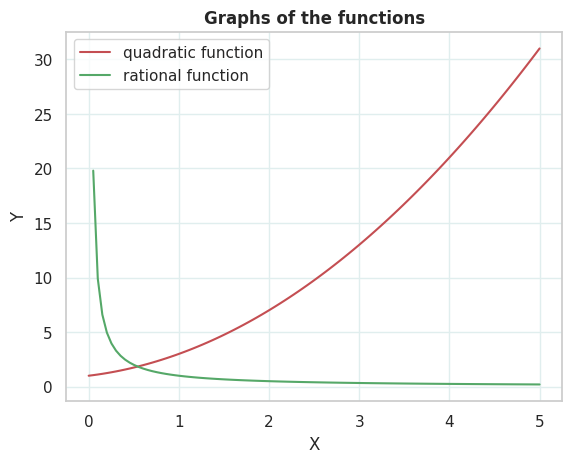

In [ ]:
x = np.linspace(0, 5, 100)
a = 1
b = 1
c = 1
y = a*x**2 + b*x + c
z = 1 / x

fig, ax = plt.subplots()
ax.set_title('Graphs of the functions', fontweight='bold')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.plot(x, y, color='r', label='quadratic function')
ax.plot(x, z, color='g', label='rational function')
plt.legend()
plt.grid(which='major', color = '#E0EEEE', linewidth = 1)
plt.grid(which='minor', color='#E0EEEE', ls=':')
plt.show()

# **Задание 6 (0.5 балла)**
Ранее мы уже проверили сбалансированность данных по разным категориям активностей в train и test сетах. Теперь визуализируйте количество сэмплов в каждой из категорий отдельно для train и test сетов, как в примере ниже. Проследите, чтобы порядок категорий слева и справа был одинаков. Иначе не очень удобно их сравнивать (когда они в разных местах двух графиков). Также заметьте, что в примере ось Х в одинаковом масштабе, что тоже удобно для сравнения.

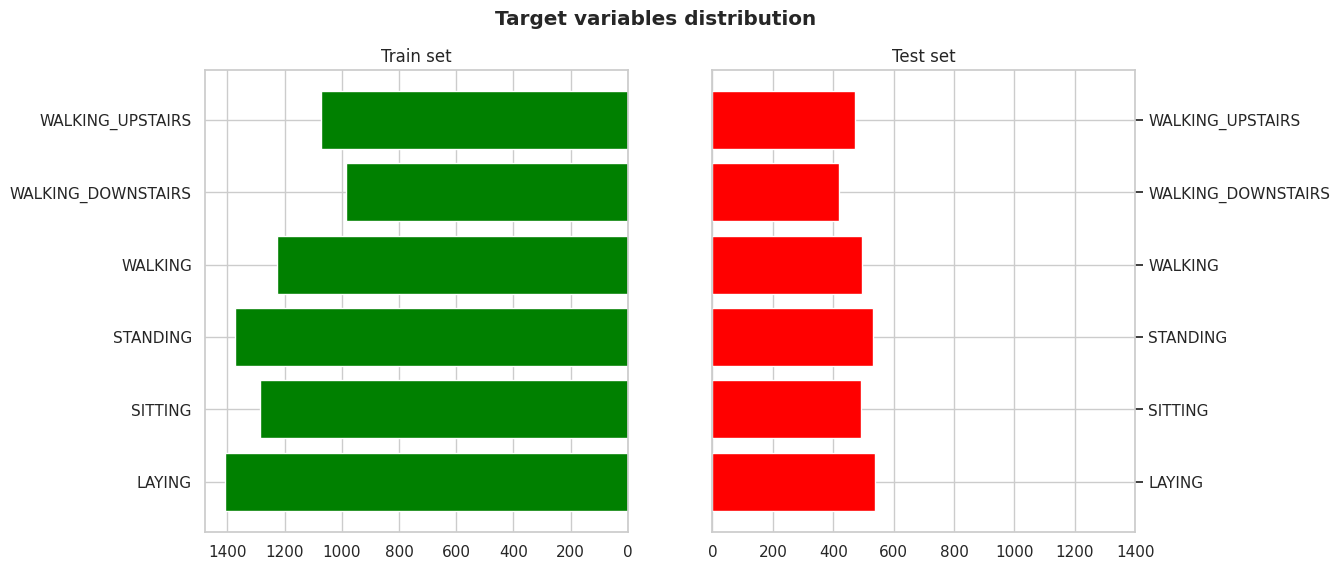

In [ ]:
train_counts = train['Activity'].value_counts()
test_counts = test['Activity'].value_counts()

train_counts = train_counts.sort_index()
test_counts = test_counts.sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False)

axes[0].barh(train_counts.index, train_counts.values, color='green')
axes[0].set_title('Train set')
axes[0].invert_xaxis()

axes[1].barh(test_counts.index, test_counts.values, color='red')
axes[1].set_xlim(0, 1400)
axes[1].set_title('Test set')
axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")

fig.suptitle('Target variables distribution', fontweight='bold')
plt.show()

# **Задание 7 (0.5 балла)**
Ранее вы выводили таблицу корреляций. Однако просто таблица корреляций не очень удобна для анализа. Что, если признаков было бы больше? Визуализируйте heatmap корреляций. Подпишите значения корреляций, округленные до 2 знаков после запятой, на графике и оставьте только те значения, которые по модулю не меньше 0.5. Будем считать такие корреляции существенными. Если будете брать код из семинарского ноутбука, то поменяйте в нем что-нибудь, например, цветовую гамму, иначе проверяющий будет карать :)

Какой признак стоит исключить из рассмотрения корреляций? Напишите его название, а также причину, почему нет смысла его рассматривать.

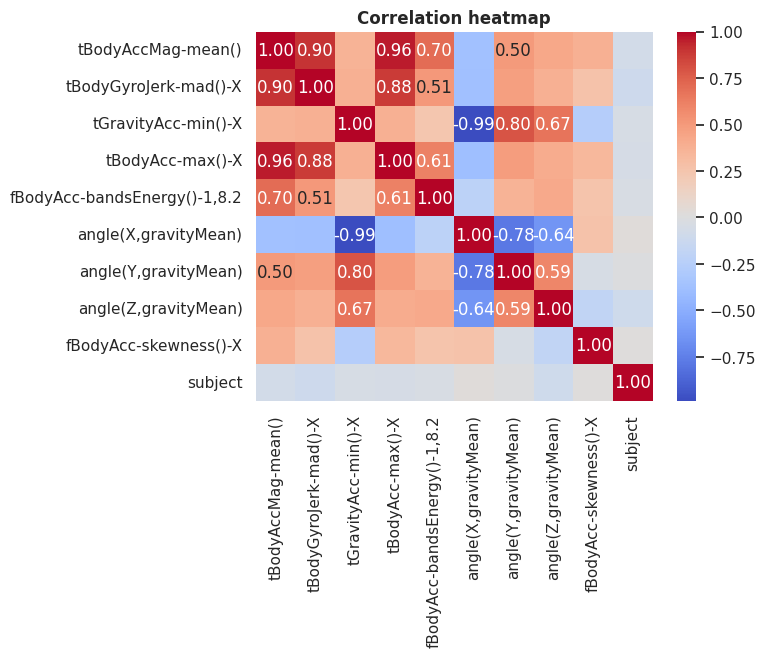

In [ ]:
ax = sns.heatmap(train.corr(numeric_only=True), annot=True, fmt ='.2f', cmap= 'coolwarm')
plt.title('Correlation heatmap', fontweight='bold')
for i in ax.texts:
  if float(i.get_text()) >= 0.5 or float(i.get_text()) <= -0.5:
        i.set_text(i.get_text())
  else:
        i.set_text('')

Основываясь на полученных данных, стоит исключить признак subject

Мы видим, что данный признак имеет минимальную корреляцию с остальными признаками. Это связано с тем, что subject - это категориальный признак. Он отражает всего лишь идентификатор испытуемого, а не полученный результат физической активности. Эти факторы не имеют линейной зависимости друг от друга

# **Задание 8 (0.5 балла)**
Для начала будем стрелять из пушки по воробьям. Выведите pairplot по всем данным train сета. Напишите, заметили ли вы в нем что-нибудь интересное, чего не было в таблицах и графиках ранее, а также сообщите, было ли вам удобно анализировать 100 графиков.

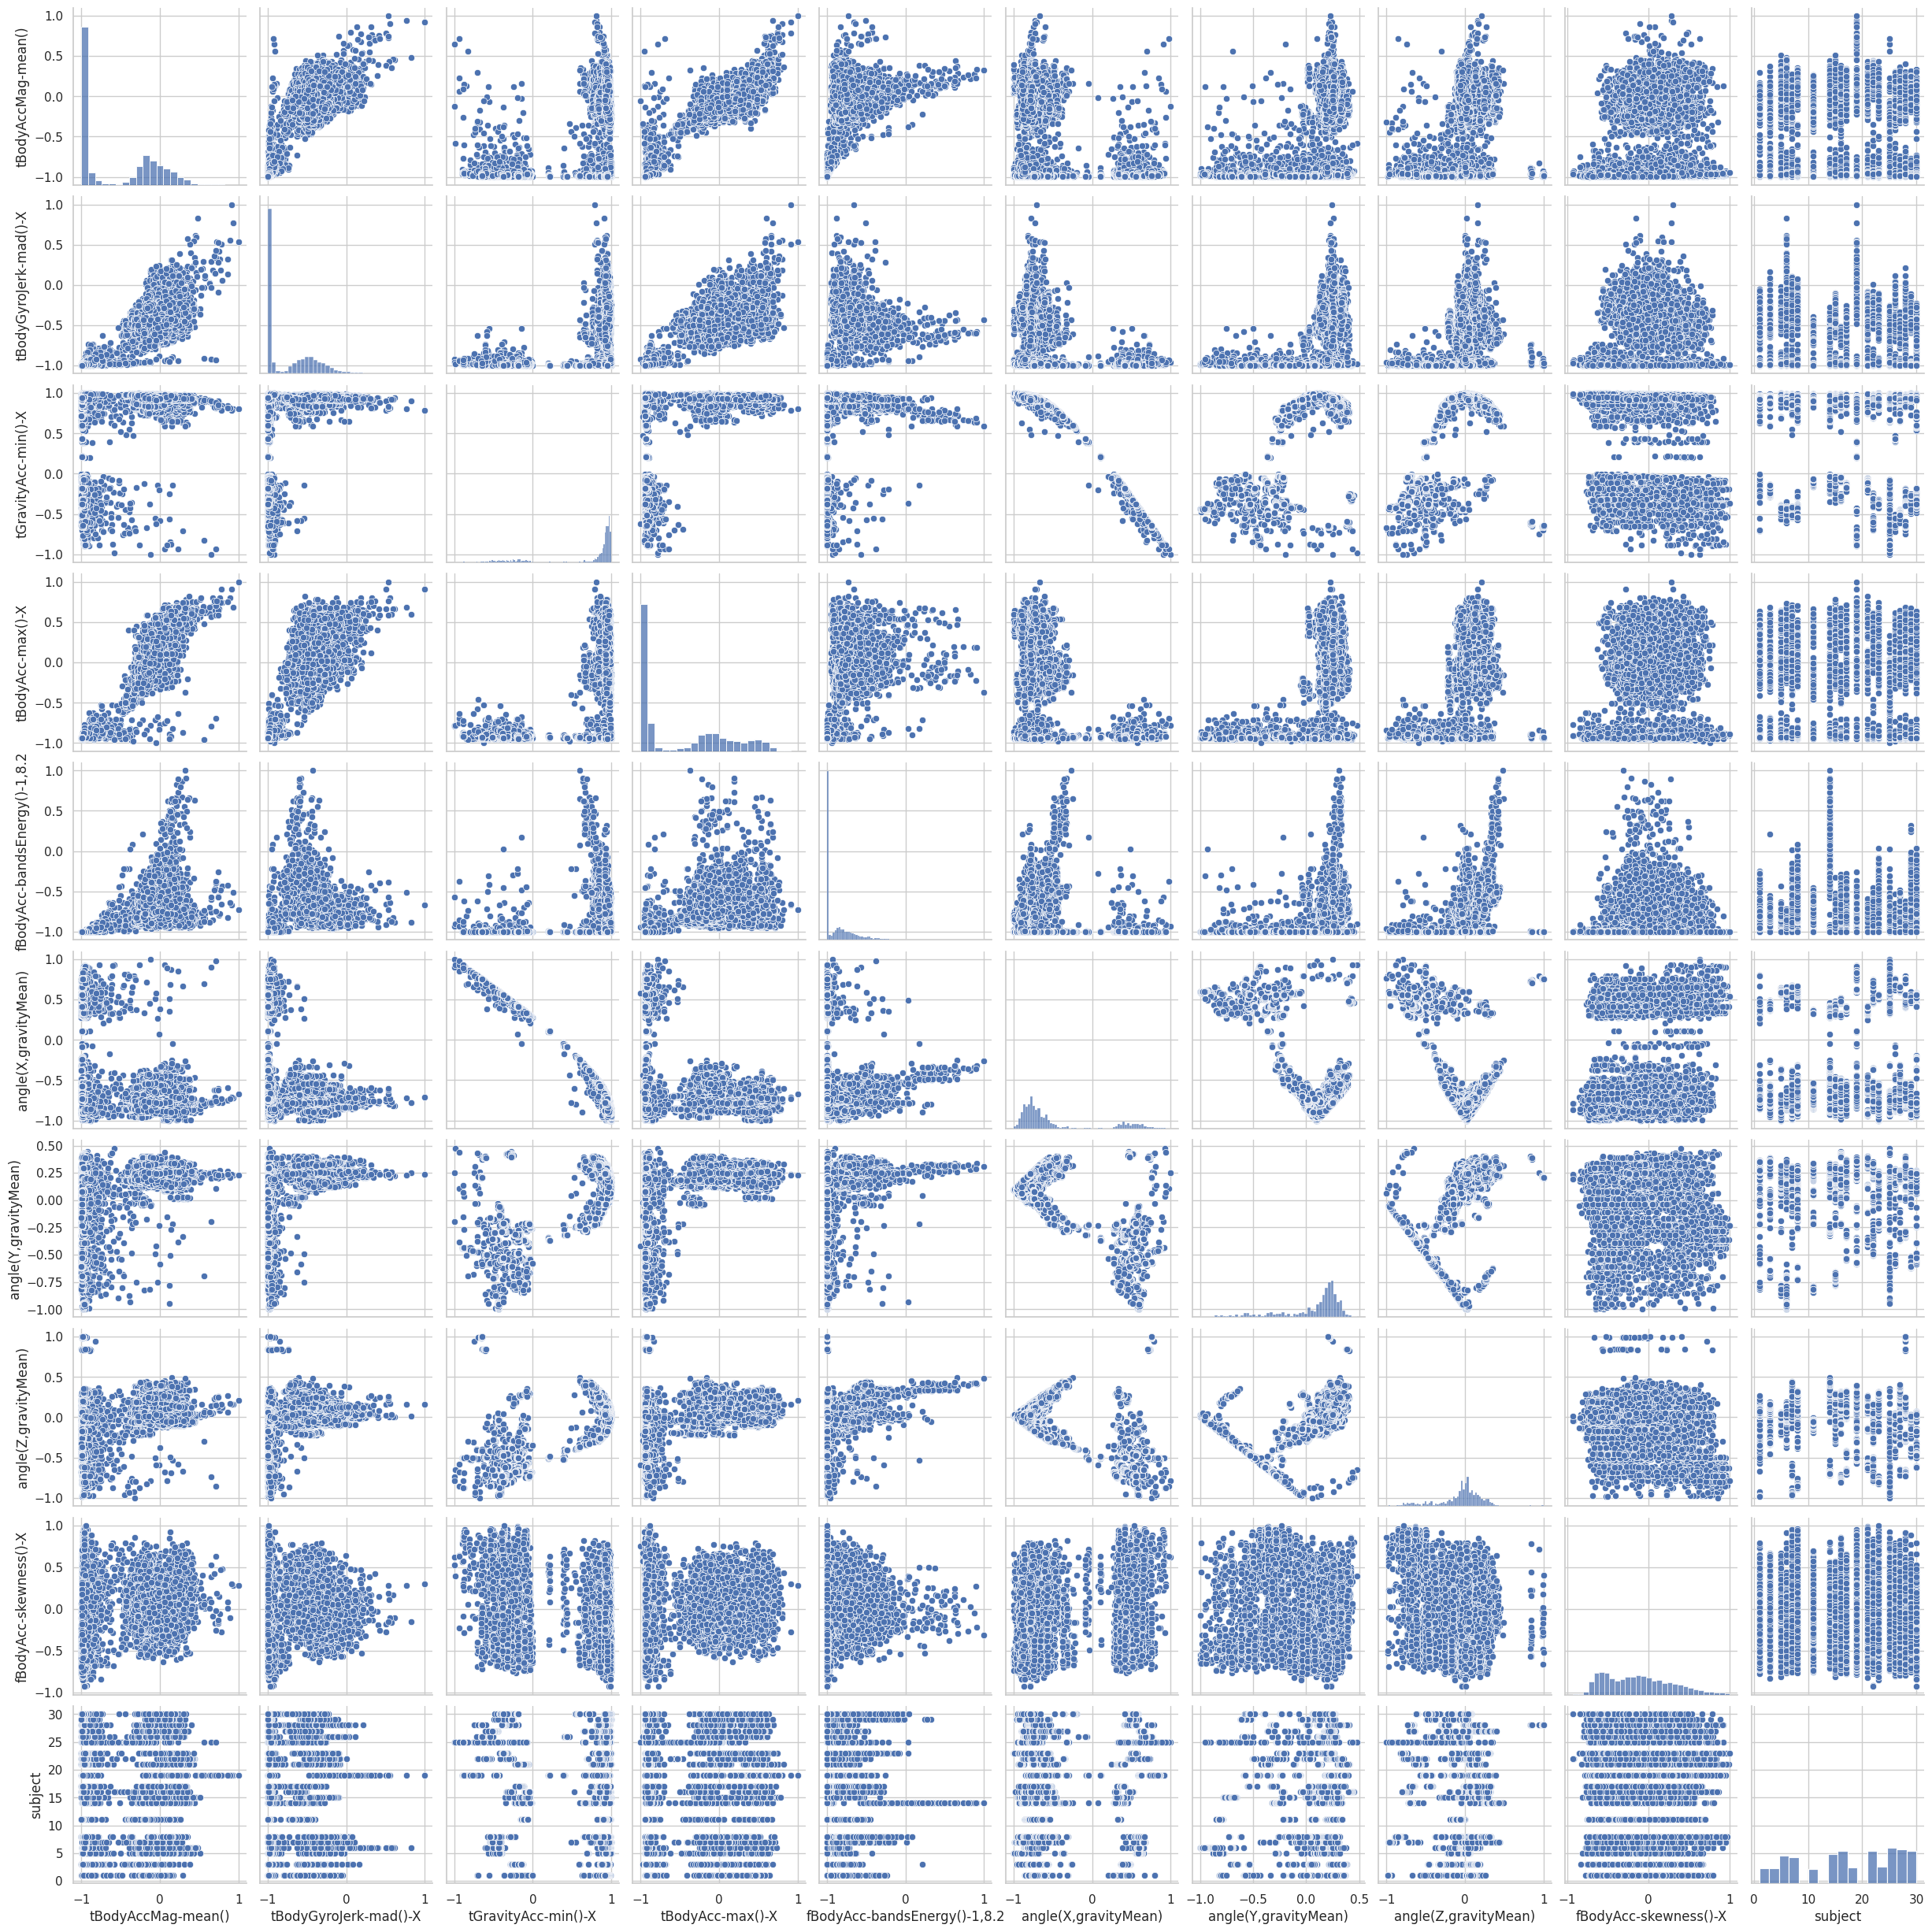

In [ ]:
sns.pairplot(train)

Кластеризация и дискретные значения в графиках с subject: Графики, где одной из осей является subject, демонстрируют четкую кластеризацию. Это подтверждает, что subject является категориальным признаком

Некоторые графики рассеяния показывают явные нелинейные зависимости между признаками. Например, между angle(X,gravityMean) и некоторыми другими признаками наблюдаются криволинейные зависимости. Это говорит о том, что линейная корреляция может быть недостаточной для описания взаимосвязи между этими признаками

Некоторые признаки (например, fBodyAcc-bandsEnergy()-1,8.2) демонстрируют скопление значений в определенных диапазонах или принимают дискретные значения

Анализировать 100 графиков было **ОЧЕНЬ НЕУДОБНО**

# **Задание 9 (1 балл)**
Окей. Смотреть на все сразу не очень удобно. Кажется, нужно смотреть на признаки в отдельности и искать в них инсайты.

Попробуем проверить гипотезу. Отобразите плотность распределения (kde) tBodyAccMag-mean() для каждой из активностей, как в примере ниже. Видите закономерность? Можно ли поделить все активности на две группы? Если да, то проведите вертикальную линию, которая визуально неплохо разделяет эти группы.

Давайте первую группу называть статическими активностями, а вторую - динамическими.

Посчитайте, какую долю правильных ответов дает ваша вертикальная линия для разделения именно этих двух групп. С чем может быть связан полученный вами результат? Предположите логическое обоснование (почему именно данный признак так хорошо/плохо разделяет группы активностей).

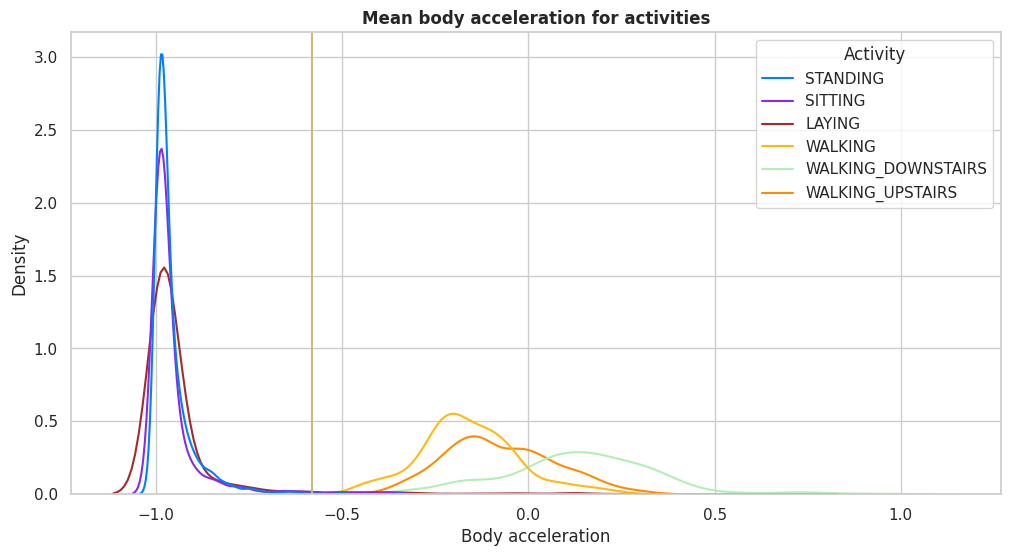

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['#007FFF', '#8A2BE2', '#A52A2A', '#FFB90F', '#B4EEB4', '#FF8C00']

ax = sns.kdeplot(data=train, x='tBodyAccMag-mean()', hue='Activity', palette=colors, legend=True)
ax.set_title('Mean body acceleration for activities', fontweight='bold')
ax.set_xlabel('Body acceleration')
ax.set_ylabel('Density')

plt.axvline(-0.58, c="y")

plt.show()

In [ ]:

print(f"Доля правильных ответов: 0.65")

Доля правильных ответов: 0.65


Если линия x=−0.58 хорошо разделяет активности, это может быть связано с тем, что значение tBodyAccMag-mean() для одной активности (например, "LAYING") значительно отличается от значений для других активностей (dynamic activities)

Например, если "LAYING" имеет более низкие значения tBodyAccMag-mean(), чем другие активности (dynamic activities), то линия x=−0.58 может эффективно разделять "LAYING" и другие static activities от остальных dynamic activities

# **Задание 10 (0.5 балла)**
Поздравляем, вы проверили первую гипотезу в процессе EDA. Однако нам бы хотелось уметь не группы разделять, а каждый отдельный вид активности. Попробуйте нарисовать "ящики с усами" для angle(X,gravityMean) с разделением по разным видам активности на данных train. Можно ли сделать какой-то вывод по полученной визуализации? Проанализируйте и проинтерпретируйте полученные картинки (если заметили какую-то особенность, может какая-то категория значительно выделяется, то предположите, почему так могло произойти).

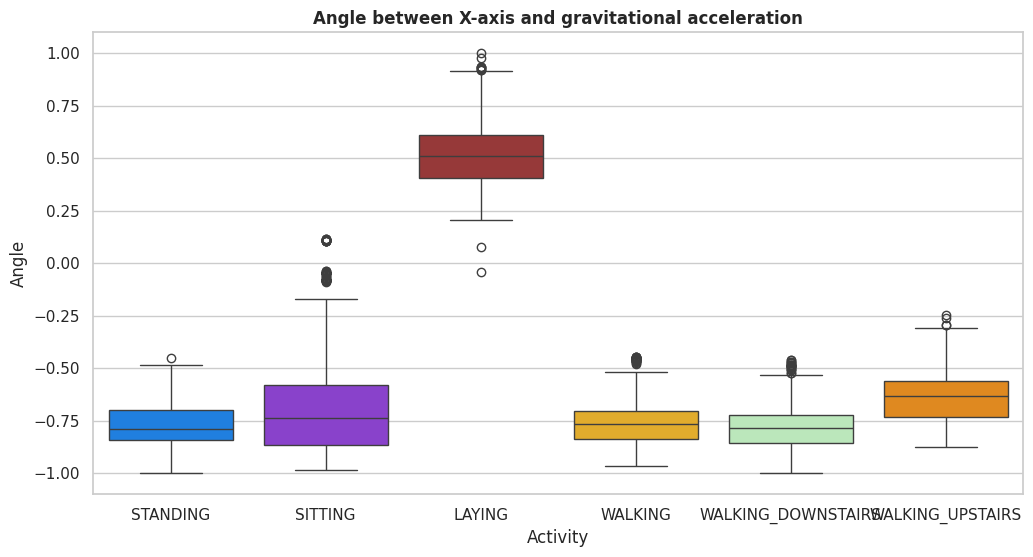

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['#007FFF', '#8A2BE2', '#A52A2A', '#FFB90F', '#B4EEB4', '#FF8C00']

ax = sns.boxplot(x='Activity', y='angle(X,gravityMean)', data=train, palette=colors)

ax.set_title('Angle between X-axis and gravitational acceleration', fontweight='bold')
ax.set_xlabel('Activity')
ax.set_ylabel('Angle')

plt.show()

Laying имеет значительно отличающееся распределение угла, так как тело находится в горизонтальном положении. Угол между осью X и гравитационным ускорением будет ближе к нулю или иметь другое характерное значение



# **Задание 11 (0.5 балла)**
Посмотрим теперь на tBodyAcc-max()-X. Визуализируйте скрипичные диаграммы для этого признака с разделением по активностям на всем train. Кажется логичным, что максимальное ускорение в моменте для разных активностей будет различаться. Однако есть ли активность, которая будет выделяться? Если да, то предложите объяснение, почему эта активность выделяется.

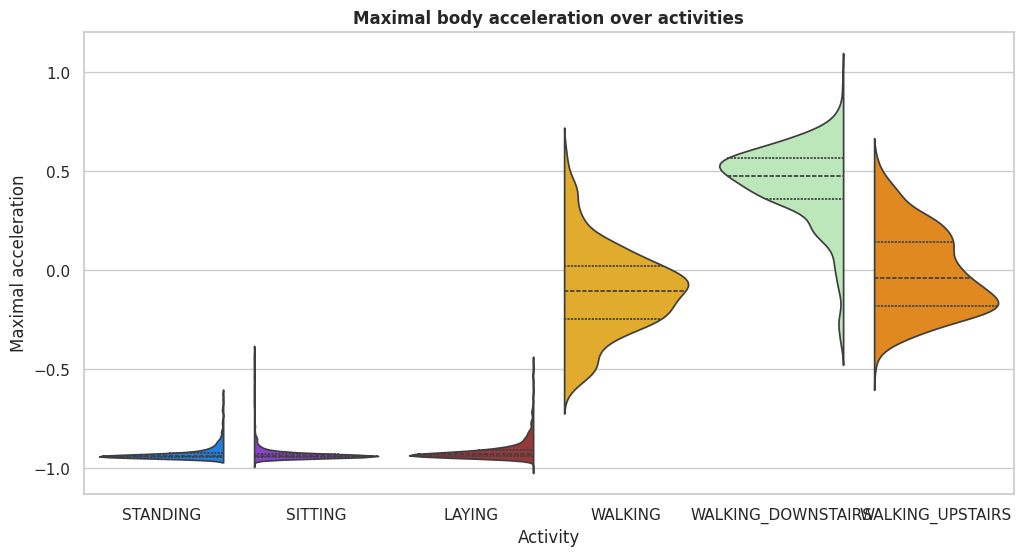

In [ ]:
plt.figure(figsize=(12, 6))
colors = ['#007FFF', '#8A2BE2', '#A52A2A', '#FFB90F', '#B4EEB4', '#FF8C00']

ax = sns.violinplot(x='Activity', y='tBodyAcc-max()-X', data=train, palette=colors, inner='quartile', split=True)
ax.set_title('Maximal body acceleration over activities', fontweight='bold')
ax.set_xlabel('Activity')
ax.set_ylabel('Maximal acceleration')

plt.show()

Анализ распределений:

STANDING и SITTING могут иметь схожие распределения максимального ускорения, так как они связаны с относительно статичными положениями тела. Максимальное ускорение в этих случаях может быть низким и схожим

LAYING также может иметь низкие значения максимального ускорения, так как тело находится в горизонтальном положении и не совершает значительных движений

WALKING, WALKING_DOWNSTAIRS, WALKING_UPSTAIRS будут иметь более высокие значения максимального ускорения из-за динамического характера движений. Однако, они могут быть схожи между собой, так как все они связаны с ходьбой

# **Задание 12 (1 балл)**
Вы уже можете с довольно хорошим качеством выделить две категории активности из шести. Продолжим.

Ранее уже упоминалось разделение на две группы активностей: статические и динамические. Пришла пора разделить датасет train на две части. Сделайте это! Теперь на одной картинке покажите распределения fBodyAcc-bandsEnergy()-1,8.2 для динамичных активностей (boxenplot - немного измененый "ящик с усами") и angle(Y,gravityMean) для статических - тут хватит и простой гистограммы (прямо, как в примере ниже). Можно ли выделить еще какие-то активности? Если да, напишите, какие активности на 1 и 2 графиках выделяются.

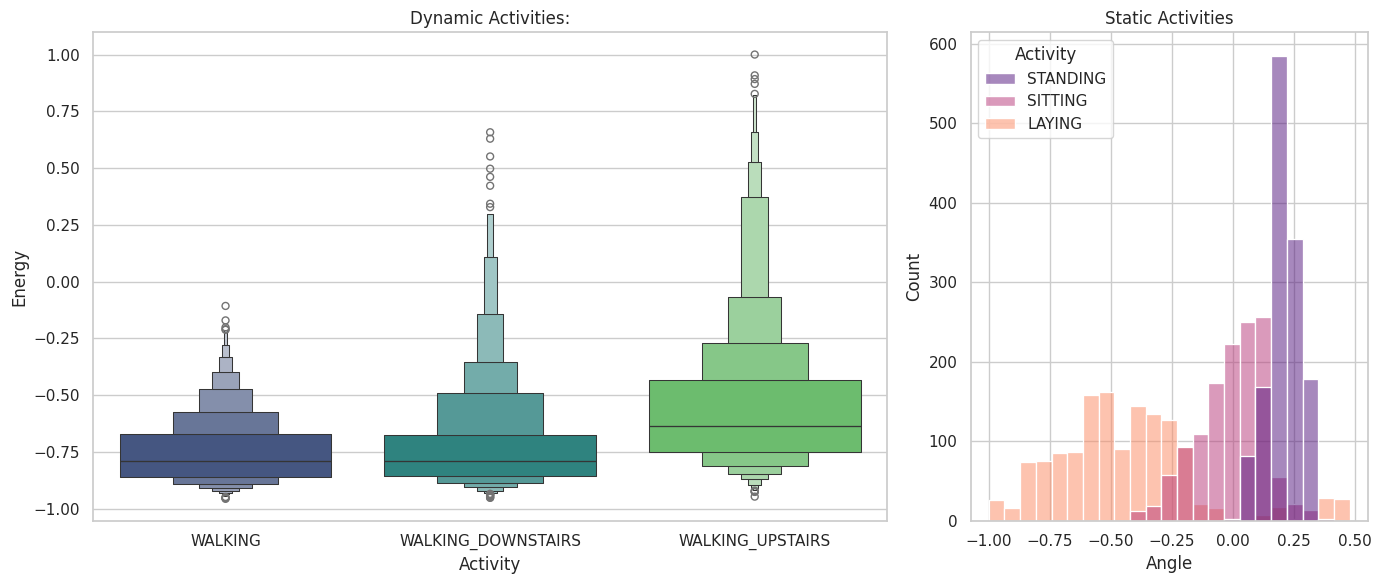

In [ ]:
dynamic_activities = ['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
static_activities = ['STANDING', 'SITTING', 'LAYING']

train_dynamic = train[train['Activity'].isin(dynamic_activities)]
train_static = train[train['Activity'].isin(static_activities)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 1]})

sns.boxenplot(x='Activity', y='fBodyAcc-bandsEnergy()-1,8.2', data=train_dynamic, ax=ax1, palette='viridis', legend=True)
ax1.set_title('Dynamic Activities:')
ax1.set_xlabel('Activity')
ax1.set_ylabel('Energy')

sns.histplot(x='angle(Y,gravityMean)', hue='Activity', data=train_static, ax=ax2,  palette='magma')
ax2.set_title('Static Activities')
ax2.set_xlabel('Angle')
ax2.set_ylabel('Count')

plt.tight_layout()
plt.show()

На 1 графике выделяется WALKING_UPSTAIRS

Ходьба вверх по лестнице требует значительных физических усилий по сравнению с обычной ходьбой или ходьбой вниз по лестнице. Это приводит к более интенсивным движениям, которые фиксируются датчиками ускорения

На 2 графике выделяется STANDING

Находясь в положении "стоя", тело находится в вертикальном положении, и ось Y (вертикальная ось) совпадает с направлением гравитационного ускорения. Это приводит к тому, что угол angle(Y,gravityMean) имеет характерное значение, которое отличается от других статических активностей

# **Задание 13 (0.5 балла)**
Не всегда жизнь будет такой легкой, а данные будут полностью или почти линейно разделимы в одному признаку (иначе чем бы занимались дата саентисты...). Часто данные вообще ни по одному признаку нельзя адекватно разделить (да и по комбинациям признаков тоже). Давайте попробуем взять не один признак, а целых два!

Рассмотрим только статические активности. Будет снова два графика сразу. На первом графике будет боксплот распределения fBodyAcc-skewness()-X по активностям. А на втором попробуем взять не все наблюдения данной группы активностей, а только их часть. Разделимы ли категории по fBodyAcc-skewness()-X? А если взять только те строки, где fBodyAcc-skewness()-X < -0.376, и теперь вывести боксплот распределения angle(Y,gravityMean) по разным активностям? Попробуйте и напишите, выделилась ли какая-то категория?

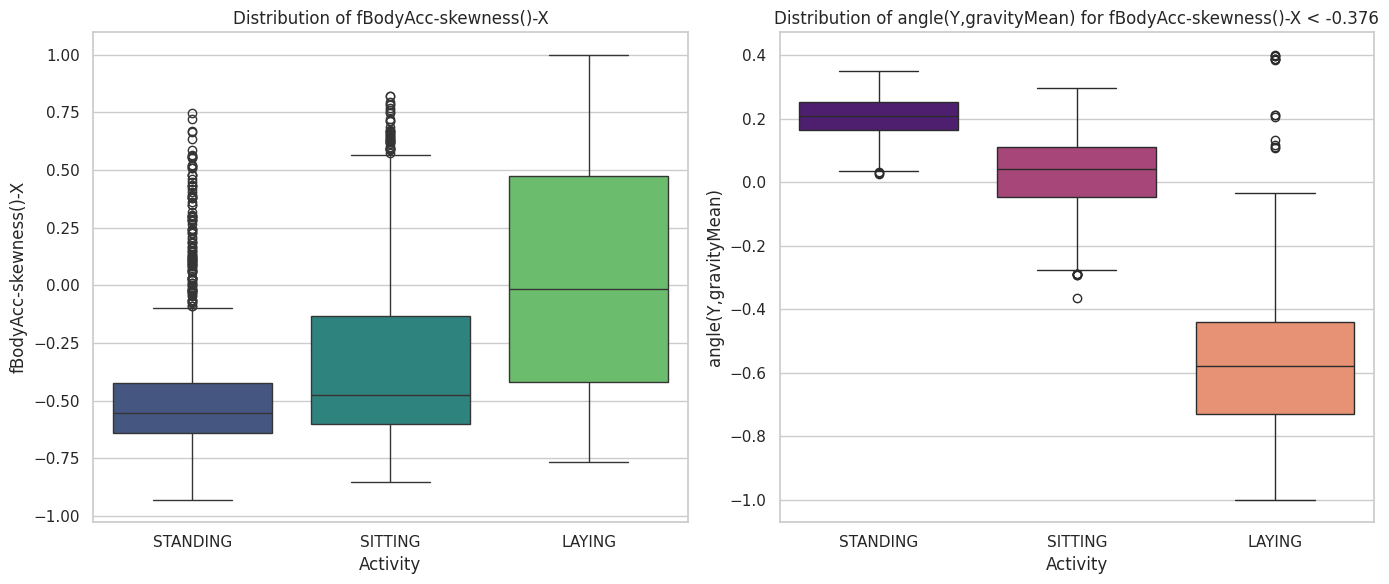

In [ ]:
static_activities = ['STANDING', 'SITTING', 'LAYING']
train_static = train[train['Activity'].isin(static_activities)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(x='Activity', y='fBodyAcc-skewness()-X', data=train_static, ax=ax1, palette='viridis')
ax1.set_title('Distribution of fBodyAcc-skewness()-X')
ax1.set_xlabel('Activity')
ax1.set_ylabel('fBodyAcc-skewness()-X')

filtered_data = train_static[train_static['fBodyAcc-skewness()-X'] < -0.376]

sns.boxplot(x='Activity', y='angle(Y,gravityMean)', data=filtered_data, ax=ax2, palette='magma')
ax2.set_title('Distribution of angle(Y,gravityMean) for fBodyAcc-skewness()-X < -0.376')
ax2.set_xlabel('Activity')
ax2.set_ylabel('angle(Y,gravityMean)')

plt.tight_layout()
plt.show()

На 1 и 2 графике выделяется LAYING

В положении лежа тело находится в горизонтальном положении, что приводит к уникальным значениям угла angle(Y,gravityMean). Если после фильтрации по fBodyAcc-skewness()-X < -0.376 распределение угла для LAYING становится более выраженным

После фильтрации LAYING имеет углы, у которых значения ниже, чем у остальных активностей

# Задание 14 (1 балл)
Вот и осталась лишь одна активность, которую мы никак не выделили. Попробуем и ее какими-то порогами отделить от всех остальных. Да, можно было бы сказать, что, раз уж мы выделили 5 из 6 категорий, то все остальное - это и есть последняя категория, но мы не идем легкими путями. Выделить оставшуюсь категорию с хорошим качеством не так уж и просто. Из доступных признаков, сначала посмотрите на распределение tBodyAcc-max()-X на динамических активностях (скрипичная диаграмма отлично подойдет).

А теперь спускаем вам порог tBodyAcc-max()-X < 0.157. Для таких строк постройте диаграмму рассеяния для признака tGravityAcc-min()-X. Да, получается неидеально, но это честная работа. Можно выбрать порог так, чтобы чисто из таблицы с динамическими активностями из строк, где tBodyAcc-max()-X < 0.157, выбрать по некоторому порогу для tGravityAcc-min()-X строки так, чтобы доля правильных ответов на оставшейся категории была не меньше 83%!

Вам может пригодиться:

plt.subplots или matplotlib.gridspec
sns.violinplot
sns.swarmplot (иногда лучше подходит, чем просто sns.scatterplot)
Обратите внимание, что подписи к осям можно убирать методами plt. Например, если у вас общее название для оси Y для обоих графиков, то можно не подписывать ось Y у второго графика.

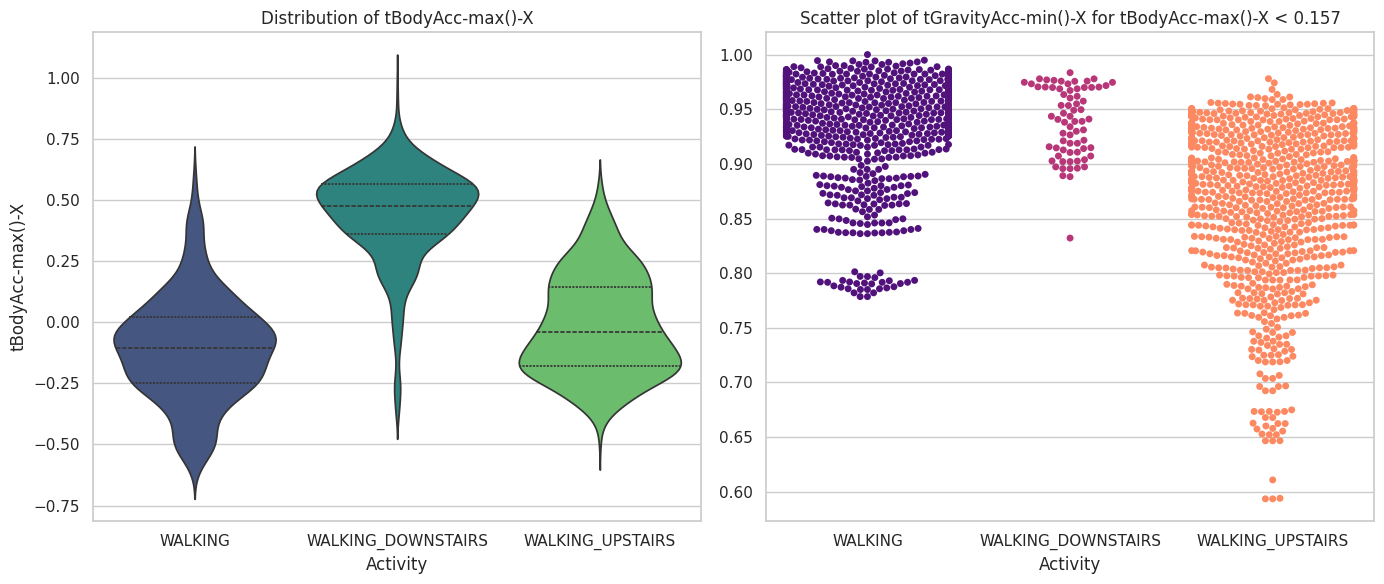

In [ ]:
dynamic_activities = ['WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
train_dynamic = train[train['Activity'].isin(dynamic_activities)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(x='Activity', y='tBodyAcc-max()-X', data=train_dynamic, ax=ax1, palette='viridis', inner='quartile')
ax1.set_title('Distribution of tBodyAcc-max()-X')
ax1.set_xlabel('Activity')
ax1.set_ylabel('tBodyAcc-max()-X')

filtered_data = train_dynamic[train_dynamic['tBodyAcc-max()-X'] < 0.157]

sns.swarmplot(x='Activity', y='tGravityAcc-min()-X', data=filtered_data, ax=ax2, palette='magma')
ax2.set_title('Scatter plot of tGravityAcc-min()-X for tBodyAcc-max()-X < 0.157')
ax2.set_xlabel('Activity')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

# **Задание 15 (0.5 балла)**
Теперь попробуем более интерактивные графики. Установите библиотеку plotly (обычно pip install plotly или conda install plotly). Синтаксис очень похож на seaborn, но вот документация для plotly.express.

Сначала подготовим данные для визуализации. Будем считать t-SNE просто "черным ящиком", который принимает наши данные и проецирует их в двумерное или трехмерное пространство. Возможно, придется немного подождать

In [ ]:
%%time
import plotly.express as px
from sklearn.manifold import TSNE

tsne_2d = TSNE(random_state=666, n_components=2)
new_2d = tsne_2d.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_2_comp = pd.concat([
    pd.DataFrame(new_2d, columns=['x', 'y']),
    train['Activity']
], axis=1)

tsne_3d = TSNE(random_state=666, n_components=3)
new_3d = tsne_3d.fit_transform(train.drop(['subject', 'Activity'], axis=1))
df_3_comp = pd.concat([
    pd.DataFrame(new_3d, columns=['x', 'y', 'z']),
    train['Activity']
], axis=1)

# 2D scatter plot
fig_2d = px.scatter(df_2_comp, x='x', y='y', color='Activity', title='2D t-SNE Visualization of Activities')
fig_2d.show()

# 3D scatter plot
fig_3d = px.scatter_3d(df_3_comp, x='x', y='y', z='z', color='Activity', title='3D t-SNE Visualization of Activities')
fig_3d.show()

CPU times: user 4min 23s, sys: 369 ms, total: 4min 24s
Wall time: 4min 25s


p.s. немного подождать ☹? я думала, у меня ноут взорвется